In [4]:
import pandas as pd
import numpy as np
np.random.seed(42)
import json

# Read Database Schema

In [5]:
def convert_spider_tables_to_df(json_path):
    # 1. Load file tables.json
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    all_records = []

    # 2. Iterasi setiap database di dalam file
    for db in data:
        db_id = db['db_id']
        table_names = db['table_names']
        column_names = db['column_names']
        column_types = db['column_types']
        primary_keys = db['primary_keys']
        
        # Mapping Foreign Keys: {index_kolom_asal: index_kolom_tujuan}
        fk_map = {fk[0]: fk[1] for fk in db['foreign_keys']}
        
        # 3. Iterasi setiap kolom untuk dapet detailnya
        for i, (table_idx, col_name) in enumerate(column_names):
            # Mapping nama tabel (kalau -1 berarti wildcard *)
            table_name = table_names[table_idx] if table_idx != -1 else "ALL"
            
            # Cek apakah kolom ini Primary Key
            is_pk = "Yes" if i in primary_keys else "No"
            
            # Cek apakah kolom ini Foreign Key & cari tujuannya
            fk_relation = "-"
            if i in fk_map:
                target_idx = fk_map[i]
                t_table_idx, t_col_name = column_names[target_idx]
                target_table_name = table_names[t_table_idx]
                fk_relation = f"{target_table_name}.{t_col_name}"
            
            # Simpan ke list
            all_records.append({
                "Database": db_id,
                "Table": table_name,
                "Column": col_name,
                "Type": column_types[i],
                "PK": is_pk,
                "FK_Relation": fk_relation
            })

    # 4. Convert jadi DataFrame
    return pd.DataFrame(all_records)

In [6]:
schema_df = convert_spider_tables_to_df('../Dataset/IDSpider/converted/idspider/tables.json')
schema_df.head(30)

,Database,Table,Column,Type,PK,FK_Relation
0,pelaku,ALL,*,text,No,-
1,pelaku,pelaku,id_pelaku,number,Yes,-
2,pelaku,pelaku,id_orang,number,No,orang.id_orang
3,pelaku,pelaku,tanggal,text,No,-
4,pelaku,pelaku,tahun,number,No,-
5,pelaku,pelaku,lokasi,text,No,-
6,pelaku,pelaku,negara,text,No,-
7,pelaku,pelaku,terbunuh,number,No,-
8,pelaku,pelaku,terluka,number,No,-
9,pelaku,orang,id_orang,number,Yes,-


In [7]:
schema_df[schema_df["Database"]=="geografis"].head()

,Database,Table,Column,Type,PK,FK_Relation
4014,geografis,ALL,*,text,No,-
4015,geografis,negara,nama_negara_bagian,text,Yes,-
4016,geografis,negara,populasi,number,No,-
4017,geografis,negara,daerah,number,No,-
4018,geografis,negara,nama_negara,text,No,-


# Create NetworkX Graph Representation 

In [8]:
import networkx as nx
import matplotlib.pyplot as plt

In [ ]:
def build_schema_graph(df):
    G = nx.Graph()
    
    # 1. Tahap Pertama: Daftarkan semua node dengan ID Unik (DB.Table.Col)
    pk_map = {} # Simpan PK per database: { 'db_name': { 'table_name': 'db.table.col_pk' } }
    
    # Bersihkan baris marker '*'
    df_clean = df[df['Column'] != '*'].copy()
    
    for _, row in df_clean.iterrows():
        db = str(row['Database']).strip()
        table = str(row['Table']).strip()
        col = str(row['Column']).strip()
        colType = str(row['Type']).strip()
        
        # ID Unik Baru: Menyertakan nama database
        node_id = f"{db}.{table}.{col}"
        
        G.add_node(node_id, 
                   type='column', 
                   database=db,
                   table=table,
                   column=col,
                   column_type=colType,
                   is_pk=(row['PK'] == 'Yes'))
        
        # Mapping PK khusus di dalam database tersebut
        if db not in pk_map:
            pk_map[db] = {}
        if row['PK'] == 'Yes':
            pk_map[db][table] = node_id

    # 2. Tahap Kedua: Buat Relasi (Hanya di dalam lingkup Database yang sama)
    for _, row in df_clean.iterrows():
        db = str(row['Database']).strip()
        table = str(row['Table']).strip()
        col = str(row['Column']).strip()
        node_id = f"{db}.{table}.{col}"
        fk_rel = str(row['FK_Relation']).strip()
        
        # A. Relasi Internal (Kolom ke PK di tabel yang sama)
        # Mencari PK milik tabel tersebut di database yang sama
        if table in pk_map[db] and node_id != pk_map[db][table]:
            G.add_edge(node_id, pk_map[db][table], relation='belongs_to_pk')
            
        # B. Relasi External (Foreign Key)
        if fk_rel != '-':
            # fk_rel di data Anda biasanya format 'target_table.target_col'
            # Kita harus menambahkan prefix database agar merujuk ke node yang benar
            target_node_id = f"{db}.{fk_rel}"
            
            if target_node_id in G.nodes:
                G.add_edge(node_id, target_node_id, relation='foreign_key')

    return G

In [68]:
# Eksekusi
graph = build_schema_graph(schema_df)

print(f"Graf Berhasil Dibuat!")
print(f"Jumlah Tabel & Kolom: {graph.number_of_nodes()}")
print(f"Jumlah Relasi: {graph.number_of_edges()}")

Graf Berhasil Dibuat!
Jumlah Tabel & Kolom: 4486
Jumlah Relasi: 3846


# Table Node Visualization

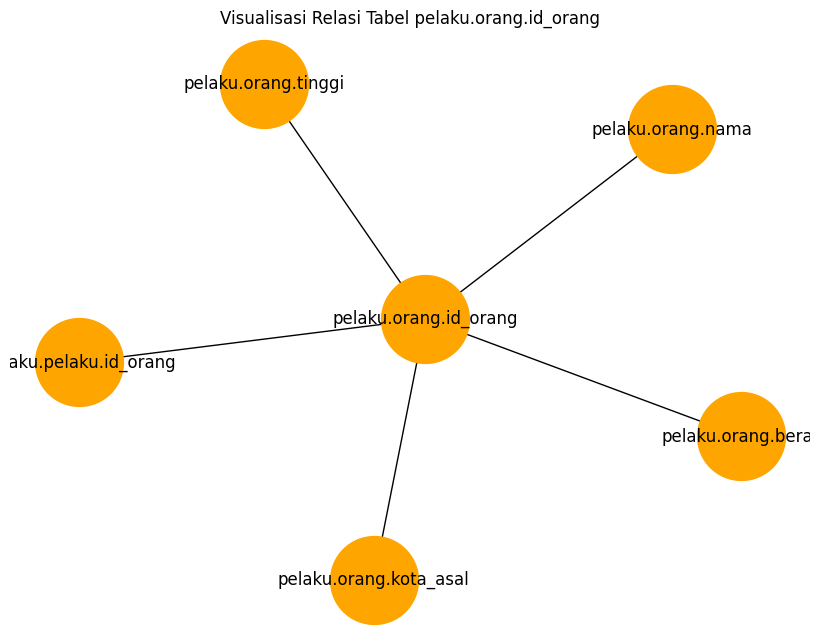

In [70]:
# Ambil tabel 'pelaku' dan semua yang terhubung langsung (radius=1)
# Kalau radius=2, bakal narik tabel lain yang punya hubungan FK
target_node = 'pelaku.orang.id_orang'
ego_G = nx.ego_graph(graph, target_node, radius=1)

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(ego_G, k=0.5)
nx.draw(ego_G, pos, with_labels=True, node_color='orange', node_size=4000)
plt.title(f"Visualisasi Relasi Tabel {target_node}")
plt.show()

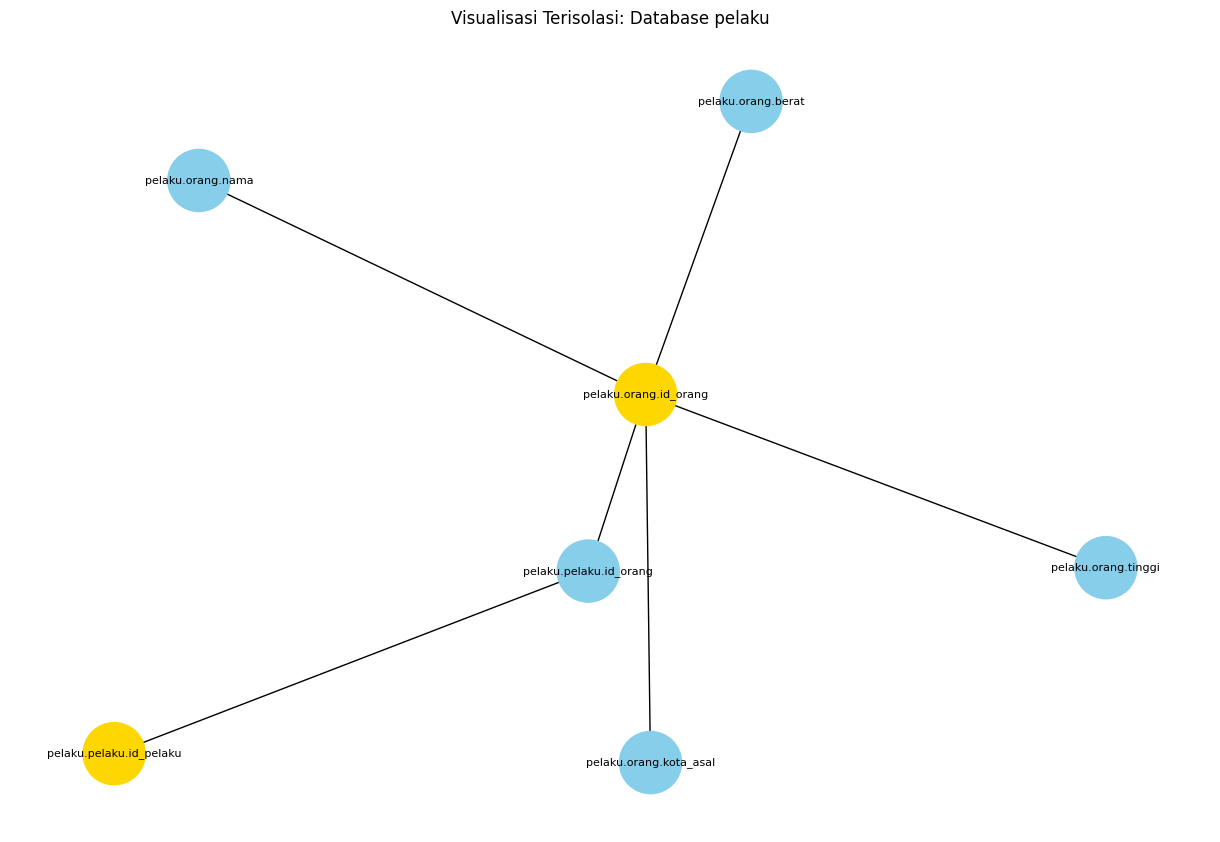

In [ ]:
target_db = "pelaku"
target_table_name = "orang"

# Cari semua node yang milik database 'pelaku' dan tabel 'orang'
nodes_to_show = [n for n, d in graph.nodes(data=True) 
                 if d.get('database') == target_db and d.get('table') == target_table_name]

# Ambil ego graph untuk melihat relasi kolom tersebut (radius 1 untuk kolom internal)
# Gunakan node pertama dari list sebagai pusat ego graph
if nodes_to_show:
    center_node = nodes_to_show[0]
    ego_G = nx.ego_graph(graph, center_node, radius=2)
    
    # Filter agar visualisasi HANYA menampilkan node dari database yang sama
    # Ini menjamin tidak ada 'penyusup' dari database lain
    clean_nodes = [n for n, d in ego_G.nodes(data=True) if d.get('database') == target_db]
    sub_G = ego_G.subgraph(clean_nodes)

    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(sub_G, k=1.5)
    
    # Bedakan warna PK dan Kolom
    colors = ['gold' if d.get('is_pk') else 'skyblue' for n, d in sub_G.nodes(data=True)]
    
    nx.draw(sub_G, pos, with_labels=True, node_color=colors, node_size=2000, font_size=8)
    plt.title(f"Visualisasi Terisolasi: Database {target_db}")
    plt.show()

# Retrieve Shortest Path

In [ ]:
def retrieve_shortest_path_2_point(G, key1, key2):
    # 1. Cari kandidat node buat keyword 1 dan keyword 2
    # Kita cari di bagian paling belakang ID (column name)
    candidates1 = [n for n, d in G.nodes(data=True) if key1.lower() in d.get('column', '').lower()]
    candidates2 = [n for n, d in G.nodes(data=True) if key2.lower() in d.get('column', '').lower()]
    
    if not candidates1 or not candidates2:
        return f"Waduh Bang, salah satu keyword nggak ketemu di graf! (Cek: {key1}, {key2})"

    # 2. Cari pasangan yang berasal dari DATABASE yang sama
    # Ini kunci biar jalurnya nggak 'cross-database'
    best_path = None
    min_length = float('inf')

    for node1 in candidates1:
        db1 = G.nodes[node1].get('database')
        for node2 in candidates2:
            db2 = G.nodes[node2].get('database')
            
            # Cuma proses kalau mereka di database yang sama
            if db1 == db2:
                try:
                    # Cari path di graph undirected biar fleksibel
                    path = nx.shortest_path(G.to_undirected(), source=node1, target=node2)
                    if len(path) < min_length:
                        min_length = len(path)
                        best_path = path
                except nx.NetworkXNoPath:
                    continue

    if best_path:
        print(f"✅ Gempi nemu jalur di database: '{G.nodes[best_path[0]].get('database')}'")
        return best_path
    else:
        return "Gak ada jalur yang nyambungin mereka!"

# --- CARA PAKAI ---
hasil_jalur = retrieve_shortest_path_2_point(graph, "nama", "terluka")

print("\nJalur yang ditemukan:")
print(" -> ".join(hasil_jalur) if isinstance(hasil_jalur, list) else hasil_jalur)

✅ Gempi nemu jalur di database: 'pelaku'

Jalur yang ditemukan:
pelaku.orang.nama -> pelaku.orang.id_orang -> pelaku.pelaku.id_orang -> pelaku.pelaku.id_pelaku -> pelaku.pelaku.terluka


# Retrieve Sub-Graph

In [75]:
def find_column_in_db(G, db_name, col_keyword):
    """
    Mencari node ID lengkap berdasarkan nama database dan keyword kolom.
    Input: "pelaku", "nama"
    Output: ["pelaku.orang.nama", "pelaku.pelaku.nama_lengkap", ...]
    """
    db_name = db_name.lower().strip()
    col_keyword = col_keyword.lower().strip()
    
    matches = []
    
    for n, d in G.nodes(data=True):
        # 1. Pastikan database-nya cocok
        if d.get('database', '').lower() == db_name:
            # 2. Pastikan tipenya adalah kolom
            if d.get('type') == 'column':
                # 3. Cek apakah keyword ada di atribut 'column' yang kita simpan
                if col_keyword in d.get('column', '').lower():
                    matches.append(n)
                    
    return matches

In [79]:
def get_schema_context(G, db_name, keywords):
    all_target_nodes = []
    
    # 1. Cari semua kandidat node untuk tiap keyword
    for key in keywords:
        found = find_column_in_db(G, db_name, key)
        if found:
            # Ambil yang pertama (atau bisa pake logic ranking kalau mau lebih pro)
            all_target_nodes.append(found[0])
            
    if not all_target_nodes:
        return "Gak ada kolom yang ketemu."

    # 2. Ambil jalur yang menghubungkan SEMUA node tersebut (Steiner Tree approach)
    # Kita mulai dari node pertama sebagai 'anchor'
    final_path_nodes = set(all_target_nodes)
    anchor = all_target_nodes[0]
    
    for target in all_target_nodes[1:]:
        try:
            # Cari jalan dari anchor ke setiap target lainnya
            path = nx.shortest_path(G.to_undirected(), source=anchor, target=target)
            final_path_nodes.update(path)
        except nx.NetworkXNoPath:
            continue
            
    return list(final_path_nodes)

In [78]:
# --- CONTOH PAKAI ---
keywords_user = ["nama", "terluka", "lokasi"]
db_user = "pelaku"

nodes_untuk_prompt = get_schema_context(graph, db_user, keywords_user)
print("Node yang terlibat buat JOIN:")
for node in nodes_untuk_prompt:
    print("- ", node)

Node yang terlibat buat JOIN:
-  pelaku.pelaku.id_pelaku
-  pelaku.pelaku.id_orang
-  pelaku.pelaku.lokasi
-  pelaku.orang.id_orang
-  pelaku.orang.nama
-  pelaku.pelaku.terluka
